In [1]:
import numpy as np 
import pandas as pd 
import os

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import h5py

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3),   

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3)    
        )

    def forward(self, x):
        return self.conv(x)

class UNetResNet34(nn.Module):
    def __init__(self, in_channels=6, num_classes=1):
        super().__init__()

        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.encoder0 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.encoder1 = resnet.layer1   # 64
        self.encoder2 = resnet.layer2   # 128
        self.encoder3 = resnet.layer3   # 256
        self.encoder4 = resnet.layer4   # 512

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder4 = ConvBlock(512, 256)

        self.upconv3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder3 = ConvBlock(256, 128)

        self.upconv2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder2 = ConvBlock(128, 64)

        self.upconv1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.decoder1 = ConvBlock(96, 32)   # 64 (e0) + 32

        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.maxpool(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        d4 = self.upconv4(e4)
        d4 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = F.interpolate(d1, size=e0.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e0], dim=1)
        d1 = self.decoder1(d1)

        out = self.final(d1)

        
        out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)

        return out

In [3]:
import os
print(os.listdir("/kaggle/input"))


['datasets']


In [4]:
print(os.listdir("/kaggle/input/datasets/bharattummala/implemetation1"))

['val_subset', 'train_subset', 'best_model.pth']


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNetResNet34(in_channels=6, num_classes=1).to(device)

model_path = "/kaggle/input/datasets/bharattummala/implemetation1/best_model.pth"

model.load_state_dict(torch.load(model_path, map_location=device))

print("Model loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 140MB/s]


Model loaded successfully


In [6]:
CHANNELS = [1, 2, 4, 6, 7, 8]

class LandslideDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        file_img = self.img_paths[idx]
        file_mask = self.mask_paths[idx]

        with h5py.File(file_img, 'r') as f:
            img = f['img'][:]

        with h5py.File(file_mask, 'r') as f:
            mask = f['mask'][:]

        if img.shape[0] == 14:
            img = img[CHANNELS, :, :]
        else:
            img = img[:, :, CHANNELS]
            img = np.transpose(img, (2, 0, 1))

        img = img / (np.max(img) + 1e-8)

        img = torch.tensor(img).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [7]:
base_path = "/kaggle/input/datasets/bharattummala/implemetation1"

train_img_dir = base_path + "/train_subset/images"
train_mask_dir = base_path + "/train_subset/masks"

val_img_dir = base_path + "/val_subset/images"
val_mask_dir = base_path + "/val_subset/masks"

In [8]:
train_dataset = LandslideDataset(train_img_dir, train_mask_dir)
val_dataset   = LandslideDataset(val_img_dir, val_mask_dir)

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [10]:
def enable_dropout_only(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout2d):
            m.train()
        else:
            m.eval()


def mc_dropout(model, x, T=30):
    enable_dropout_only(model)

    preds = []

    with torch.no_grad():
        for _ in range(T):
            out = torch.sigmoid(model(x))
            preds.append(out)

    preds = torch.stack(preds)
    

    
    mean = preds.mean(dim=0)
    uncertainty = preds.std(dim=0)
    uncertainty = uncertainty * (mean > 0.2)
    
    

    return mean, uncertainty

In [11]:
idx = 20

img, mask = val_dataset[idx]

img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

mean_pred, uncertainty = mc_dropout(model, img)

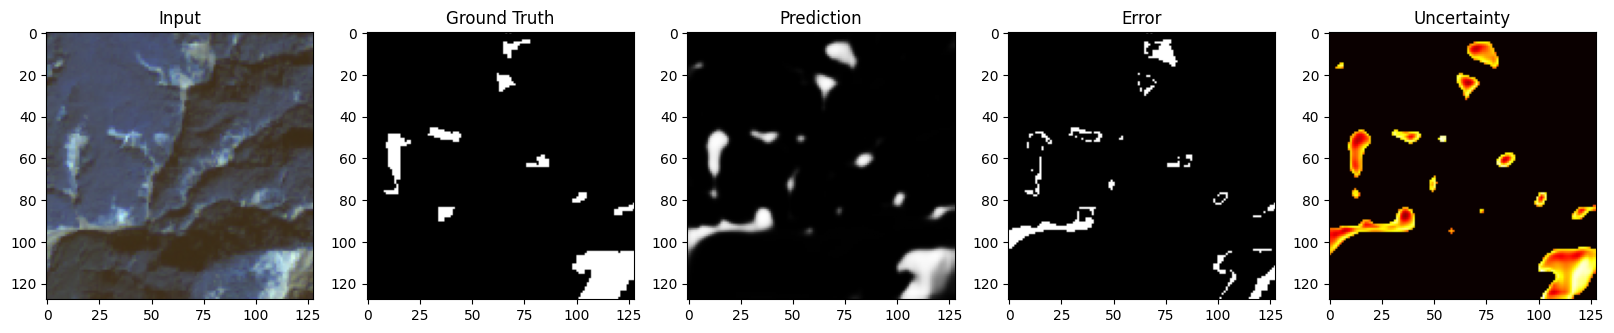

In [12]:
import matplotlib.pyplot as plt

img_np = img[0].cpu().permute(1,2,0).numpy()
pred_np = mean_pred[0][0].cpu().numpy()
mask_np = mask[0][0].cpu().numpy()

unc_np = uncertainty[0][0].cpu().numpy()
unc_np = (unc_np - unc_np.min()) / (unc_np.max() - unc_np.min() + 1e-8)

# error map 
pred_bin = (mean_pred > 0.5).float()
error_map = (pred_bin != mask).float()
error_np = error_map[0][0].cpu().numpy()



plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
plt.title("Input")
plt.imshow(img_np[:,:,:3])

plt.subplot(1,5,2)
plt.title("Ground Truth")
plt.imshow(mask_np, cmap='gray')

plt.subplot(1,5,3)
plt.title("Prediction")
plt.imshow(pred_np, cmap='gray')

plt.subplot(1,5,4)
plt.title("Error")
plt.imshow(error_np, cmap='gray')

plt.subplot(1,5,5)
plt.title("Uncertainty")
plt.imshow(unc_np, cmap='hot')

plt.show()